# Definindo Parametros

## Modelo: LightGBM

O objetivo desse notebook é analisar o funcionamento do modelo de classificação LightGBM para definir o gênero de uma música com base nas suas audio features. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import os
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Leitura dos Dados

In [3]:
caminho_arquivo = '../data/spotify_songs.csv'

df = pd.read_csv(caminho_arquivo)

features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'explicit', 'tempo']


## Limpeza do dataset: removendo duplicatas

Percebemos ao abrir o dataset em uma planilha que havia muitas músicas repetidas com IDs diferentes, pois o Spotify indica um ID distindo para músicas iguais que são republicadas em albuns diferentes, por exemplo. Tendo em vista isso fizemos uma limpeza nessas duplicatas.

In [4]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.copy()

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [5]:
# Selecionamos as colunas das audio features que importam
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicando a clusterização: K-Means

Resolvemos aplicar o modelo não supervisionado K-means para organizar nossas músicas em grupos com base nas suas audio features, uma vez que se considerássemos apenas a coluna `track_genre` para fazermos nossa classificação o modelo teria que lidar com 114 classes e apresentaria baixos valores de f1-score e acurácia.

In [6]:
print("Treinando o K-Means...")
kmeans = KMeans(n_clusters=15, random_state=42, n_init='auto')
df['macrogenero'] = kmeans.fit_predict(X_scaled)

print("Clusterização concluída! Nova coluna 'macrogenero' criada.")

Treinando o K-Means...
Clusterização concluída! Nova coluna 'macrogenero' criada.


## Modelo LightGBM

Nossa abordagem de classificação seguirá em duas etapas.

- Etapa 1:

Treinaremos um modelo para conseguir identificar a que cluster uma determinada música pertence

- Etapa 2:

Sabendo o cluster que a música pertence, aplicaremos um modelo especialista dentro do subset do cluster para definir o gênero real associado a música.

Abaixo está a elaboração do modelo LightGBM Roteador, que será o responsável pela classificação mais geral (clusters)

In [7]:
# Separando em Treino e Teste (80% para treinar, 20% para testar)
X_train, X_test, y_train, y_test = train_test_split(
    X, df['macrogenero'], test_size=0.2, random_state=42
)

# Instanciando e Treinando o LightGBM
print("Iniciando o treinamento do LightGBM")
roteador = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,    # Número de árvores
    learning_rate=0.1,   # Velocidade de aprendizado
    n_jobs=-1            # Usa todos os núcleos do seu processador
)

roteador.fit(X_train, y_train)

# 3. Fazendo previsões na base de teste
y_pred = roteador.predict(X_test)

# 4. Imprimindo a Acurácia Geral
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Iniciando o treinamento do LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000931 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2294
[LightGBM] [Info] Number of data points in the train set: 65075, number of used features: 10
[LightGBM] [Info] Start training from score -1.875759
[LightGBM] [Info] Start training from score -2.609637
[LightGBM] [Info] Start training from score -2.675917
[LightGBM] [Info] Start training from score -3.362834
[LightGBM] [Info] Start training from score -4.546604
[LightGBM] [Info] Start training from score -3.082946
[LightGBM] [Info] Start training from score -2.831110
[LightGBM] [Info] Start training from score -2.062543
[LightGBM] [Info] Start training from score -3.483394
[LightGBM] [Info] Start training from score -3.009893
[LightGBM] [Info] Start training from score -2.692800
[LightGBM] [Info]

Como já definimos nosso modelo geral, precisamos treinar nossos modelos especialistas para cada cluster (vibe)

In [8]:
# Criamos um dicionário vazio para guardar nossos modelos
especialistas = {}

todas_as_vibes = df['macrogenero'].unique()

print("Treinando os Especialistas (com Filtro de Ruído)...\n")

# Variável de controle: Um gênero precisa ter pelo menos 15 músicas 
# dentro de um cluster para ser levado a sério pelo especialista
MIN_MUSICAS_POR_GENERO = 15

for vibe in todas_as_vibes:
    df_vibe = df[df['macrogenero'] == vibe]
    
    # Realizamos um  filtro dentro do cluster para garantir que os gêneros dentro dele
    # sejam possuam presença considerável, e não uma ou outra música perdida
    contagem = df_vibe['track_genre'].value_counts()
    generos_fortes = contagem[contagem >= MIN_MUSICAS_POR_GENERO].index
    df_vibe_limpo = df_vibe[df_vibe['track_genre'].isin(generos_fortes)]

    if len(df_vibe_limpo['track_genre'].unique()) <= 1:
        genero_unico = contagem.index[0] 
        especialistas[vibe] = genero_unico
        print(f"[{vibe}] - Ruído muito alto. Ficará fixo no gênero principal: '{genero_unico}'.")
        continue

    # Definimos X e y usando o dataframe limpo
    X_especialista = df_vibe_limpo[features]
    y_especialista = df_vibe_limpo['track_genre']
    
    # 3. Treinar o mini-modelo especialista
    modelo_especialista = lgb.LGBMClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1, verbose=-1)
    modelo_especialista.fit(X_especialista, y_especialista)
    
    # 4. Salva o modelo treinado
    especialistas[vibe] = modelo_especialista
    print(f"[{vibe}] - Especialista treinado! Gêneros reduzidos para: {len(y_especialista.unique())} (Eram {len(contagem)}).")

print("\nTodos os 15 especialistas estão prontos e blindados contra ruído!")


Treinando os Especialistas (com Filtro de Ruído)...

[0] - Especialista treinado! Gêneros reduzidos para: 98 (Eram 110).
[1] - Especialista treinado! Gêneros reduzidos para: 66 (Eram 96).
[10] - Especialista treinado! Gêneros reduzidos para: 75 (Eram 109).
[13] - Especialista treinado! Gêneros reduzidos para: 85 (Eram 107).
[7] - Especialista treinado! Gêneros reduzidos para: 102 (Eram 113).
[14] - Especialista treinado! Gêneros reduzidos para: 88 (Eram 112).
[6] - Especialista treinado! Gêneros reduzidos para: 79 (Eram 113).
[9] - Especialista treinado! Gêneros reduzidos para: 46 (Eram 95).
[12] - Especialista treinado! Gêneros reduzidos para: 33 (Eram 78).
[5] - Especialista treinado! Gêneros reduzidos para: 19 (Eram 40).
[2] - Especialista treinado! Gêneros reduzidos para: 39 (Eram 94).
[3] - Especialista treinado! Gêneros reduzidos para: 53 (Eram 102).
[8] - Especialista treinado! Gêneros reduzidos para: 37 (Eram 89).
[11] - Especialista treinado! Gêneros reduzidos para: 36 (Eram 7

A função `classificar_musica_hierarquicamente` será a responsável por receber as audio features de uma música como entrada e cuspir tanto o cluster quanto o gênero da música

In [9]:
def classificar_musica_hierarquicamente(audio_features_nova_musica):
    """
    Recebe um DataFrame de 1 linha contendo as features numéricas da música.
    Exemplo: audio_features_nova_musica = X_test.iloc[[0]]
    """
    vibe_predita = roteador.predict(audio_features_nova_musica)[0]
    
    especialista = especialistas[vibe_predita]
    
    # Se o especialista for só uma string (caso de gênero único visto acima)
    if isinstance(especialista, str):
        genero_predito = especialista
    else:
        # Pede para o mini-modelo decidir qual é o gênero final
        genero_predito = especialista.predict(audio_features_nova_musica)[0]
        
    return vibe_predita, genero_predito

## Testando a nossa cascata com uma música aleatória

In [10]:
# Sorteia 1 índice (linha) aleatório APENAS DA BASE DE TESTE (Dados Inéditos)
indice_sorteado = X_test.sample(n=1).index[0]

# Extrai as informações usando esse índice
musica_sorteada_features = X_test.loc[[indice_sorteado]]
vibe_real = y_test.loc[indice_sorteado]
genero_real = df.loc[indice_sorteado, 'track_genre']
nome_musica = df.loc[indice_sorteado, 'track_name']
artista_musica = df.loc[indice_sorteado, 'artists']

vibe_predita, genero_predito = classificar_musica_hierarquicamente(musica_sorteada_features)

print("="*60)
print(f"MÚSICA SORTEADA: {nome_musica} - {artista_musica}")
print("="*60)
print("GABARITO REAL (O QUE ELA REALMENTE É):")
print(f"  - Macrogenero Original: {vibe_real}")
print(f"  - Gênero Original:    {genero_real}")
print("-" * 60)
print("PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:")
print(f"  - Fase 1 (Roteador) previu a Vibe:  -> '{vibe_predita}'")
print(f"  - Fase 2 (Especialista) previu o Gênero: -> '{genero_predito}'")
print("="*60)

# Verificação de acerto visual
if genero_real == genero_predito:
    print("✅ RESULTADO: O modelo ACERTOU NA MOSCA!")
elif vibe_real == vibe_predita:
    print("⚠️ RESULTADO: Acertou a Macrogenero, mas confundiu o subgênero.")
else:
    print("❌ RESULTADO: O modelo errou a previsão.")

MÚSICA SORTEADA: Get Get Down - Get Get Nerio's Dubwork Remix - Paul Johnson;Nerio
GABARITO REAL (O QUE ELA REALMENTE É):
  - Macrogenero Original: 0
  - Gênero Original:    chicago-house
------------------------------------------------------------
PREVISÃO DO NOSSO PIPELINE DE MACHINE LEARNING:
  - Fase 1 (Roteador) previu a Vibe:  -> '0'
  - Fase 2 (Especialista) previu o Gênero: -> 'chicago-house'
✅ RESULTADO: O modelo ACERTOU NA MOSCA!


## Visualizando matriz de confusão e gráfico de importância de features

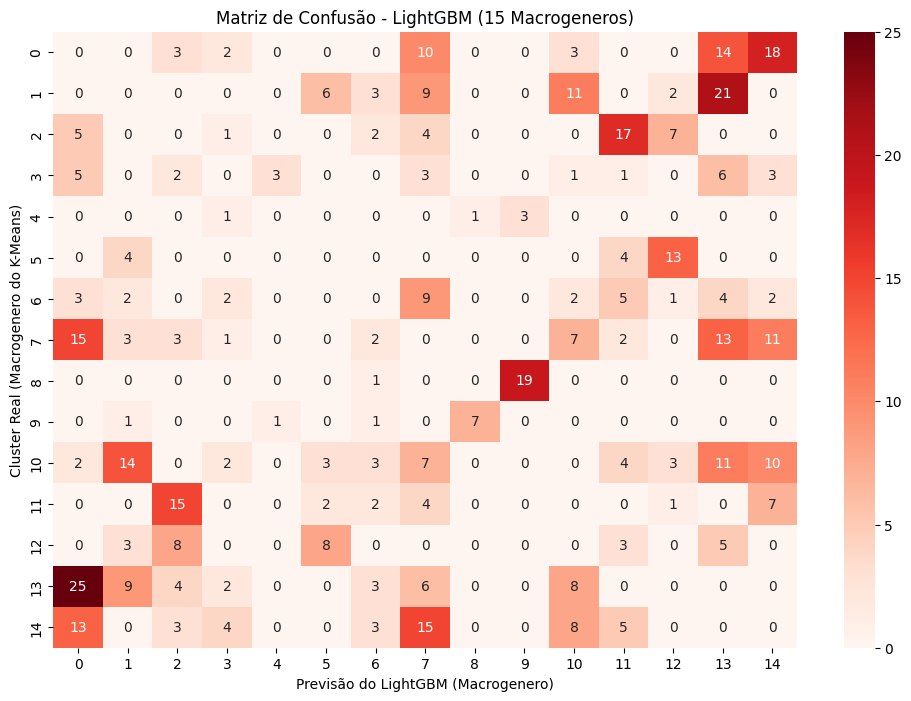

<Figure size 1000x600 with 0 Axes>

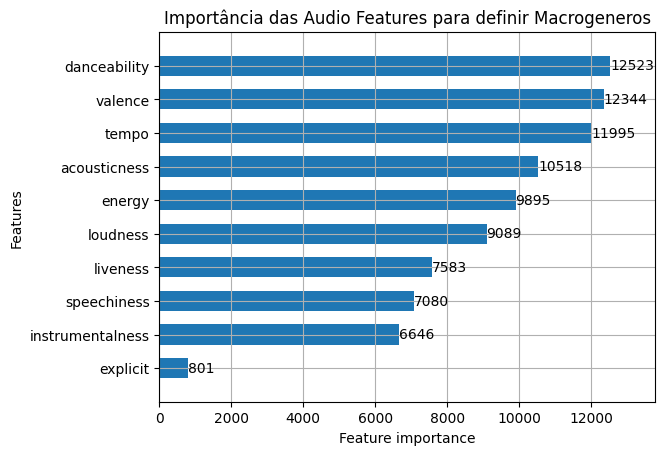

In [11]:
# Matriz de confusão
plt.figure(figsize=(12, 8))
conf_matrix = confusion_matrix(y_test, y_pred)

np.fill_diagonal(conf_matrix, 0)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Previsão do LightGBM (Macrogenero)')
plt.ylabel('Cluster Real (Macrogenero do K-Means)')
plt.title('Matriz de Confusão - LightGBM (15 Macrogeneros)')
plt.show()

# Importância das features
plt.figure(figsize=(10, 6))

lgb.plot_importance(roteador, max_num_features=10, height=0.6, 
                    title='Importância das Audio Features para definir Macrogeneros')
plt.show()

## Salvando nosso modelo treinado

In [12]:
# 1. Garantir que a pasta existe (opcional, mas evita erros)
os.makedirs("../backend/models/lightgbm", exist_ok=True)

# 2. Salvar o Modelo Roteador (A Fase 1)
caminho_roteador = "../backend/models/lightgbm/lightgbm_roteador.pkl"
joblib.dump(roteador, caminho_roteador)
print(f"Roteador salvo em: {caminho_roteador}")

# 3. Salvar os Modelos Especialistas (A Fase 2)
for cluster_id, modelo_especialista in especialistas.items():
    caminho_especialista = f"../backend/models/lightgbm/lightgbm_especialista_cluster_{cluster_id}.pkl"
    
    # Salva cada modelo com o nome do seu respectivo cluster
    joblib.dump(modelo_especialista, caminho_especialista)

print(f"Todos os {len(especialistas)} especialistas foram salvos com sucesso!")

Roteador salvo em: ../backend/models/lightgbm/lightgbm_roteador.pkl
Todos os 15 especialistas foram salvos com sucesso!


In [15]:
dicionario_busca = {}

for linha in df.iterrows():
    id = linha['track_id']
    dicionario_busca[id] = {
        "nome": linha['track_name'],
        "artista": linha['artists'],
        "audio_features": {
            "track_id": id,
            "danceability": linha['danceability'],
            "energy": linha['energy'],
            "loudness": linha['loudness'],
            "speechiness": linha['speechiness'],
            "acousticness": linha['acousticness'],
            "instrumentalness": linha['instrumentalness'],
            "liveness": linha['liveness'],
            "valence": linha['valence'],
            "tempo": linha['tempo'],
            "explicit": 1 if linha.get('explicit', False) else 0
        }
    }

# Salva esse novo arquivo na pasta do backend
joblib.dump(dicionario_busca, '../backend/models/dicionario_busca.pkl')
print("Dicionário de Busca salvo com sucesso!")

TypeError: tuple indices must be integers or slices, not str